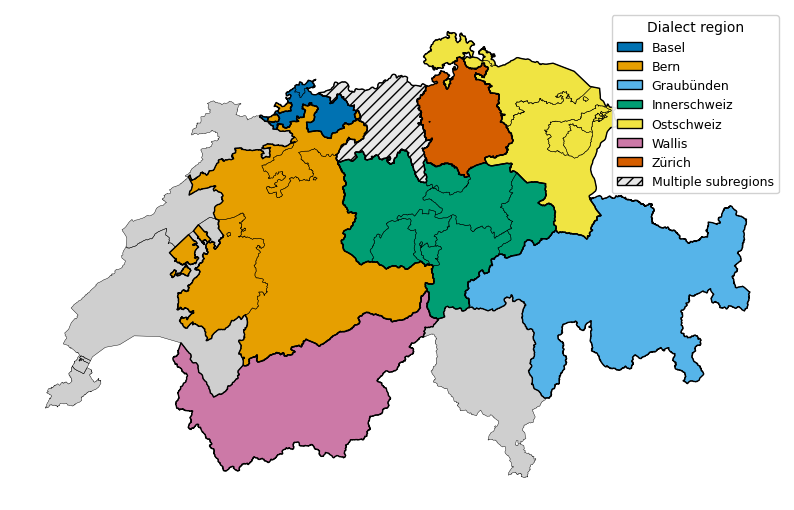

In [19]:
import geopandas as gpd, matplotlib.pyplot as plt, matplotlib.patches as mpatches

GPKG = "regions/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"
LAYER = "tlm_kantonsgebiet"
COL = "name"

region = {
    "Basel-Stadt":"Basel", "Basel-Landschaft":"Basel",
    "Bern":"Bern", "Fribourg":"Bern", "Solothurn":"Bern",
    "Luzern":"Innerschweiz", "Schwyz":"Innerschweiz", "Obwalden":"Innerschweiz",
    "Nidwalden":"Innerschweiz", "Uri":"Innerschweiz", "Glarus":"Innerschweiz", "Zug":"Innerschweiz",
    "St. Gallen":"Ostschweiz", "Thurgau":"Ostschweiz", "Schaffhausen":"Ostschweiz",
    "Appenzell Innerrhoden":"Ostschweiz", "Appenzell Ausserrhoden":"Ostschweiz",
    "Graubünden":"Graubünden",
    "Valais":"Wallis",
    "Zürich":"Zürich",
    "Aargau":"Multiple subregions",
    "Genève":None, "Vaud":None, "Neuchâtel":None, "Jura":None, "Ticino":None,
}

colors = {
    "Basel":        "#0072B2",
    "Bern":         "#E69F00",
    "Graubünden":   "#56B4E9",
    "Innerschweiz": "#009E73",
    "Ostschweiz":   "#F0E442",
    "Wallis":       "#CC79A7",
    "Zürich":       "#D55E00",
}
other_color = "#cfcfcf"      # non-region cantons (single grey)
mixed_color  = "#e8e8e8"     # Aargau fill (hatched on top)

cantons = gpd.read_file(GPKG, layer=LAYER)
cantons["region"] = cantons[COL].map(region)

unmapped = sorted(set(cantons[COL]) - set(region))
if unmapped:
    print("UNMAPPED (add to dict):", unmapped)

fig, ax = plt.subplots(figsize=(10, 7))

# Non-region cantons (single light grey)
cantons[cantons.region.isna()].plot(ax=ax, color=other_color, edgecolor="none")

# Region fills
for r, c in colors.items():
    sub = cantons[cantons.region == r]
    if not sub.empty:
        sub.dissolve().plot(ax=ax, color=c, edgecolor="none")

# Aargau: hatched, to read as "split" rather than another grey
mixed = cantons[cantons.region == "Multiple subregions"]
if not mixed.empty:
    mixed.dissolve().plot(ax=ax, facecolor=mixed_color, edgecolor="black",
                          linewidth=0.3, hatch="///")

# Thin canton borders (black)
cantons.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.3)

# Thicker region borders (black)
for r in list(colors) + ["Multiple subregions"]:
    sub = cantons[cantons.region == r]
    if not sub.empty:
        sub.dissolve().plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.0)

handles = [mpatches.Patch(facecolor=c, edgecolor="black", label=r) for r, c in colors.items()]
handles.append(mpatches.Patch(facecolor=mixed_color, edgecolor="black",
                              hatch="///", label="Multiple subregions"))
ax.legend(handles=handles, loc="upper right", fontsize=9, title="Dialect region",
          title_fontsize=10, frameon=True, framealpha=0.9)
ax.set_axis_off()
plt.savefig("regions/dialect-regions.pdf", bbox_inches="tight")
plt.show()